# Supervised Modeling — AI4I · SCANIA · Pump

Binary classification: **Will this equipment fail?** (0 = Normal, 1 = Failure)

| Dataset | Table | Label | Notes |
|---------|-------|-------|-------|
| AI4I 2020 | `FactSensorReadings` WHERE source='AI4I' | `label_binary` | Synthetic, clean labels, 3.4% failure |
| SCANIA | `FactFleetEvents` | `has_failed` | Real trucks, vehicle-level label |
| Pump | `FactSensorReadings` WHERE source='Pump' | `label_binary` | `Maintenance_Flag` = maintenance needed |

MetroPT3 is excluded — it has no ground-truth labels and is handled separately
in `modeling_unsupervised.ipynb`.


In [1]:
# Cell 1: Imports
import json, warnings
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             classification_report, matthews_corrcoef)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline
print("Imports OK")


Imports OK


In [2]:
# Cell 2: DB config
RANDOM_STATE = 42
DB_PASSWORD  = "Rana@2019!"
DB_USER, DB_HOST, DB_PORT, DB_NAME = "postgres", "localhost", "5432", "predictive_maintenance_dwh"

def get_engine():
    url = f"postgresql://{DB_USER}:{quote_plus(DB_PASSWORD)}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    return create_engine(url)

engine = get_engine()
print("Engine ready.")


Engine ready.


In [7]:
q_ai4i = """
    SELECT source_system,
           temperature_celsius,
           rpm,
           torque_nm,
           tool_wear_min,
           label_binary
    FROM maintenance.FactSensorReadings
    WHERE source_system = 'AI4I'
      AND label_binary IS NOT NULL
"""

# ── Pump ──────────────────────────────────────────────────────────────────────
# Pump: Remove any LIMIT that might be filtering rows
q_pump = """
    SELECT source_system,
           temperature_celsius,
           pressure_bar,
           rpm,
           vibration,
           label_binary
    FROM maintenance.FactSensorReadings
    WHERE source_system = 'Pump'
      AND label_binary IS NOT NULL
"""

# ── SCANIA ────────────────────────────────────────────────────────────────────
# FactFleetEvents stores sensor_readings as JSONB and has_failed as the label.
q_scania = """
    SELECT 
        'SCANIA' AS source_system,
        has_failed::int AS label_binary,
        (sensor_readings->>'171_0')::float AS sensor_171,
        (sensor_readings->>'666_0')::float AS sensor_666,
        (sensor_readings->>'427_0')::float AS sensor_427,
        (sensor_readings->>'837_0')::float AS sensor_837,
        (sensor_readings->>'167_0')::float AS sensor_167
    FROM maintenance.FactFleetEvents fe
    JOIN maintenance.DimEquipment de ON fe.equipment_key = de.equipment_key
    WHERE de.source_system = 'SCANIA'
      AND fe.sensor_readings IS NOT NULL
    ORDER BY fe.time_step
"""

with engine.connect() as conn:
    df_ai4i  = pd.read_sql(text(q_ai4i),  conn)
    df_pump  = pd.read_sql(text(q_pump),  conn)
    df_scania = pd.read_sql(text(q_scania), conn)

print(f"AI4I   : {len(df_ai4i):>8,} rows | failure rate: {df_ai4i['label_binary'].mean()*100:.2f}%")
print(f"Pump   : {len(df_pump):>8,} rows | failure rate: {df_pump['label_binary'].mean()*100:.2f}%")
print(f"SCANIA : {len(df_scania):>8,} rows | failure rate: {df_scania['label_binary'].mean()*100:.2f}%")


AI4I   :   10,000 rows | failure rate: 3.39%
Pump   :   20,000 rows | failure rate: 49.84%
SCANIA : 1,122,452 rows | failure rate: 100.00%


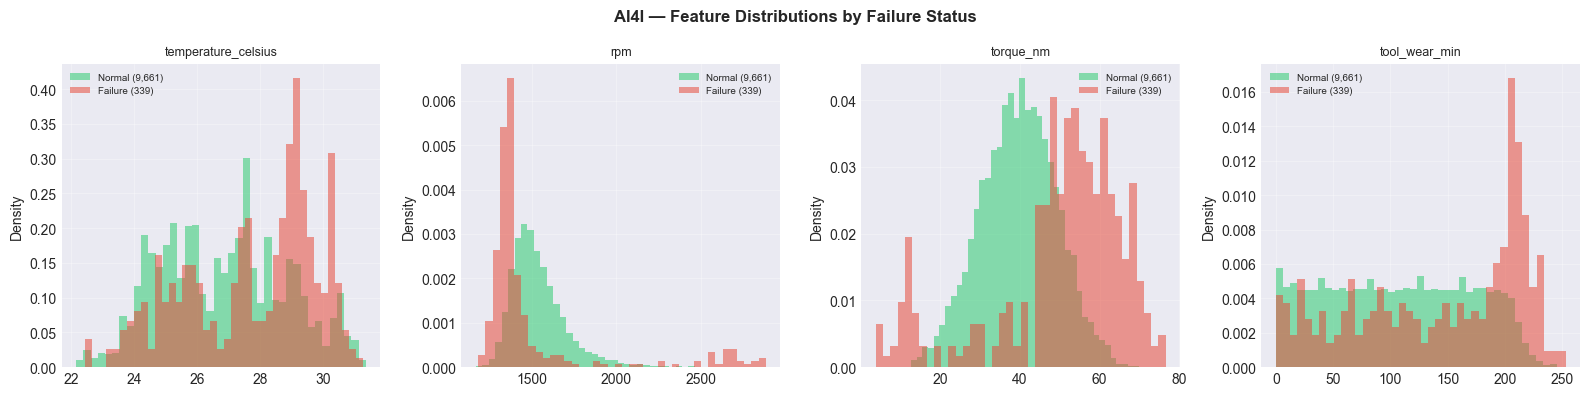

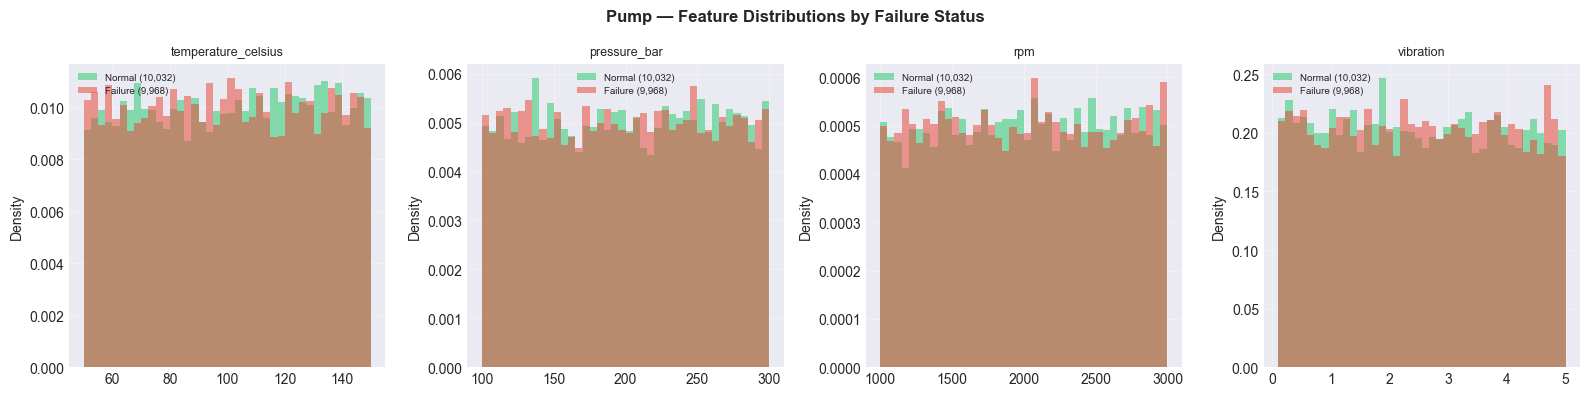

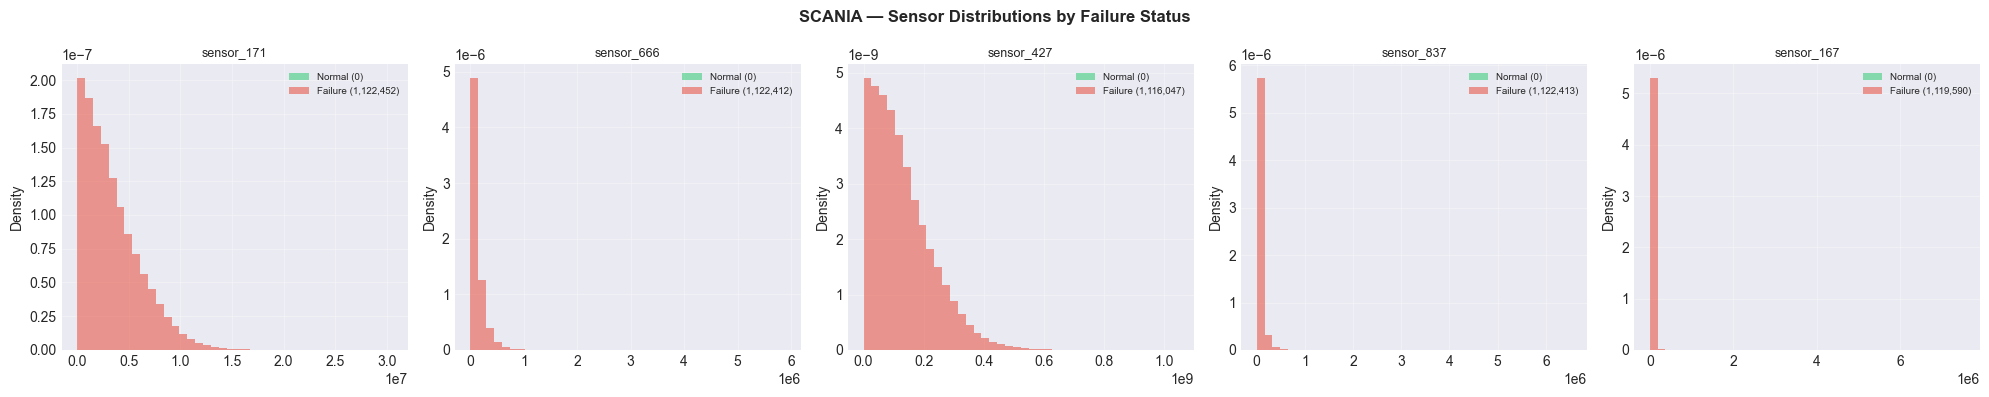

In [8]:
# Cell 4: EDA — per-dataset feature distributions
def plot_distributions(df, feature_cols, label_col, title, color_normal='#2ecc71', color_fail='#e74c3c'):
    cols = [c for c in feature_cols if c in df.columns]
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, cols):
        n_data = df[df[label_col]==0][col].dropna()
        f_data = df[df[label_col]==1][col].dropna()
        ax.hist(n_data, bins=40, alpha=0.55, density=True, color=color_normal,
                label=f'Normal ({len(n_data):,})')
        ax.hist(f_data, bins=40, alpha=0.55, density=True, color=color_fail,
                label=f'Failure ({len(f_data):,})')
        ax.set_title(col, fontsize=9); ax.set_ylabel('Density')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

plot_distributions(df_ai4i,
    ['temperature_celsius','rpm','torque_nm','tool_wear_min'],
    'label_binary', 'AI4I — Feature Distributions by Failure Status')

plot_distributions(df_pump,
    ['temperature_celsius','pressure_bar','rpm','vibration'],
    'label_binary', 'Pump — Feature Distributions by Failure Status')

plot_distributions(df_scania,
    ['sensor_171','sensor_666','sensor_427','sensor_837','sensor_167'],
    'label_binary', 'SCANIA — Sensor Distributions by Failure Status')


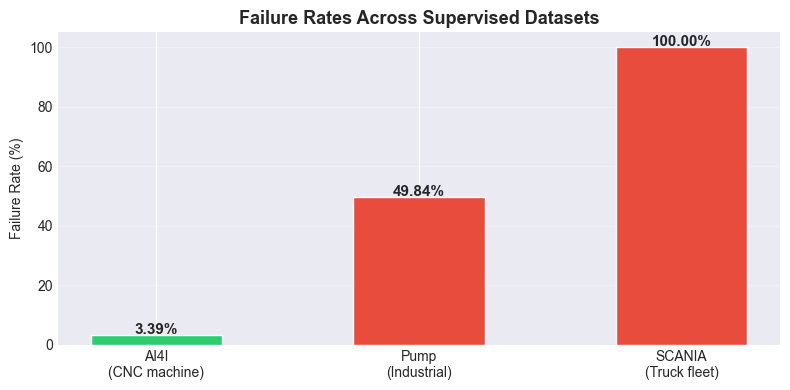

In [9]:
# Cell 5: Failure rate summary
fig, ax = plt.subplots(figsize=(8, 4))
datasets = {
    'AI4I\n(CNC machine)':    df_ai4i['label_binary'].mean(),
    'Pump\n(Industrial)':     df_pump['label_binary'].mean(),
    'SCANIA\n(Truck fleet)':  df_scania['label_binary'].mean(),
}
colors = ['#e74c3c' if v > 0.4 else '#f39c12' if v > 0.1 else '#2ecc71'
          for v in datasets.values()]
bars = ax.bar(datasets.keys(), [v*100 for v in datasets.values()],
              color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, datasets.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val*100:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Failure Rate (%)')
ax.set_title('Failure Rates Across Supervised Datasets', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


In [10]:
# Cell 6: Preprocessors and model factory

def make_numeric_pipe(cols):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
    ])

def build_preprocessor(numeric_cols):
    return ColumnTransformer([
        ('num', make_numeric_pipe(numeric_cols), numeric_cols),
    ])

def get_models(preprocessor, neg, pos):
    spw = neg / max(pos, 1)
    return {
        'Random Forest': Pipeline([
            ('pre', preprocessor),
            ('model', RandomForestClassifier(
                n_estimators=250, max_depth=10, min_samples_leaf=3,
                class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        'Gradient Boosting': Pipeline([
            ('pre', preprocessor),
            ('model', GradientBoostingClassifier(
                n_estimators=180, learning_rate=0.06, max_depth=3,
                random_state=RANDOM_STATE))
        ]),
        'Deep Neural Network': Pipeline([
            ('pre', preprocessor),
            ('model', MLPClassifier(
                hidden_layer_sizes=(64,32,16), activation='relu', solver='adam',
                alpha=0.001, learning_rate_init=0.001, max_iter=350,
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=20, random_state=RANDOM_STATE))
        ]),
    }


In [15]:
# Cell 7: Train + evaluate on a single dataset (FIXED for single-class)
def run_experiment(df, feature_cols, label_col, dataset_name):
    print(f"\n{'='*60}")
    print(f"DATASET: {dataset_name}")
    print(f"{'='*60}")

    feat = [c for c in feature_cols if c in df.columns]
    X = df[feat].copy()
    y = df[label_col].astype(int)

    # Check if we have both classes
    unique_classes = y.unique()
    print(f"  Unique classes in target: {unique_classes}")
    
    if len(unique_classes) < 2:
        print(f"  ⚠️ WARNING: Only one class present ({unique_classes[0]})")
        print(f"  → Skipping {dataset_name} (cannot train binary classifier)")
        
        # Return empty results
        empty_df = pd.DataFrame(columns=['dataset', 'algorithm', 'accuracy', 'f1', 
                                          'roc_auc', 'avg_prec', 'mcc', 'recall_fail', 
                                          'cv_f1_mean', 'cv_f1_std', 'confusion_matrix'])
        return empty_df, {}, {}, {}, None, None, feat

    # Check minimum samples per class
    min_class_count = min(y.value_counts())
    if min_class_count < 2:
        print(f"  ⚠️ WARNING: {min_class_count} samples in minority class")
        print(f"  → Skipping {dataset_name} (need at least 2 per class for stratification)")
        
        empty_df = pd.DataFrame(columns=['dataset', 'algorithm', 'accuracy', 'f1', 
                                          'roc_auc', 'avg_prec', 'mcc', 'recall_fail', 
                                          'cv_f1_mean', 'cv_f1_std', 'confusion_matrix'])
        return empty_df, {}, {}, {}, None, None, feat

    # Only use stratification if both classes exist and have enough samples
    stratify = y if y.value_counts().min() >= 2 else None
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=stratify)

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    print(f"  Train: {len(X_train):,}  Test: {len(X_test):,}")
    print(f"  Failure rate — train: {pos/len(y_train)*100:.2f}%  test: {(y_test==1).sum()/len(y_test)*100:.2f}%")

    pre = build_preprocessor(feat)
    models = get_models(pre, neg, pos)
    cv = StratifiedKFold(n_splits=min(5, min_class_count), shuffle=True, random_state=RANDOM_STATE)

    results = []
    trained, preds, probs = {}, {}, {}

    for name, pipe in models.items():
        print(f"  Training {name} ...", end=" ")
        pipe.fit(X_train, y_train)
        trained[name] = pipe
        y_pred = pipe.predict(X_test)
        
        # Handle predict_proba safely
        try:
            y_prob = pipe.predict_proba(X_test)
            if y_prob.shape[1] == 2:
                y_prob = y_prob[:, 1]
            else:
                # Only one class predicted
                y_prob = y_prob[:, 0]
        except Exception:
            y_prob = y_pred  # fallback
        
        preds[name] = y_pred
        probs[name] = y_prob

        # Cross-validation (skip if not enough classes)
        try:
            cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1', n_jobs=-1)
            cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
        except Exception:
            cv_mean, cv_std = 0.0, 0.0

        cm = confusion_matrix(y_test, y_pred)
        if cm.size == 4:
            tn, fp, fn, tp = cm.ravel()
        else:
            tn, fp, fn, tp = cm[0,0], 0, 0, cm[1,1] if cm.size > 1 else 0

        # Calculate metrics safely
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        recall = tp / max(tp + fn, 1)
        prec = tp / max(tp + fp, 1)
        
        try:
            roc_auc = roc_auc_score(y_test, y_prob)
        except Exception:
            roc_auc = 0.5  # random guess if only one class
            
        try:
            avg_prec = average_precision_score(y_test, y_prob)
        except Exception:
            avg_prec = 0.0
            
        try:
            mcc = matthews_corrcoef(y_test, y_pred)
        except Exception:
            mcc = 0.0

        results.append({
            'dataset': dataset_name,
            'algorithm': name,
            'accuracy': accuracy,
            'f1': f1,
            'roc_auc': roc_auc,
            'avg_prec': avg_prec,
            'mcc': mcc,
            'recall_fail': recall,
            'cv_f1_mean': cv_mean,
            'cv_f1_std': cv_std,
            'confusion_matrix': cm.tolist(),
        })
        print(f"F1={f1:.4f}  AUC={roc_auc:.4f}  CV-F1={cv_mean:.4f}±{cv_std:.4f}")

    return pd.DataFrame(results), trained, preds, probs, X_test, y_test, feat

In [16]:
# Cell 8: Run all three datasets (with SCANIA check)

ai4i_feat   = ['temperature_celsius', 'rpm', 'torque_nm', 'tool_wear_min']
pump_feat   = ['temperature_celsius', 'pressure_bar', 'rpm', 'vibration']
scania_feat = ['sensor_171', 'sensor_666', 'sensor_427', 'sensor_837', 'sensor_167']

# Check SCANIA before running
scania_has_both_classes = len(df_scania['label_binary'].unique()) > 1

print("\n" + "="*70)
print("CHECKING DATASETS")
print("="*70)
print(f"AI4I unique classes: {df_ai4i['label_binary'].unique()} → OK")
print(f"Pump unique classes: {df_pump['label_binary'].unique()} → OK")
print(f"SCANIA unique classes: {df_scania['label_binary'].unique()} → {'OK' if scania_has_both_classes else 'SKIP (only one class)'}")

# Run experiments
res_ai4i, tr_ai4i, pr_ai4i, pb_ai4i, Xt_ai4i, yt_ai4i, _ = run_experiment(
    df_ai4i, ai4i_feat, 'label_binary', 'AI4I')

res_pump, tr_pump, pr_pump, pb_pump, Xt_pump, yt_pump, _ = run_experiment(
    df_pump, pump_feat, 'label_binary', 'Pump')

# Only run SCANIA if it has both classes
if scania_has_both_classes:
    res_scania, tr_scania, pr_scania, pb_scania, Xt_scania, yt_scania, _ = run_experiment(
        df_scania, scania_feat, 'label_binary', 'SCANIA')
    all_results = pd.concat([res_ai4i, res_pump, res_scania], ignore_index=True)
else:
    print("\n⚠️ SKIPPING SCANIA: Only one class (100% failures) — cannot train binary classifier")
    all_results = pd.concat([res_ai4i, res_pump], ignore_index=True)

print("\n" + "="*60)
print("FULL RESULTS TABLE")
print("="*60)
print(all_results[['dataset', 'algorithm', 'f1', 'roc_auc', 'mcc', 'cv_f1_mean']].to_string(index=False))


CHECKING DATASETS
AI4I unique classes: [0 1] → OK
Pump unique classes: [1 0] → OK
SCANIA unique classes: [1] → SKIP (only one class)

DATASET: AI4I
  Unique classes in target: [0 1]
  Train: 7,500  Test: 2,500
  Failure rate — train: 3.39%  test: 3.40%
  Training Random Forest ... F1=0.6364  AUC=0.9704  CV-F1=0.6070±0.0387
  Training Gradient Boosting ... F1=0.5231  AUC=0.9697  CV-F1=0.5415±0.0527
  Training Deep Neural Network ... F1=0.5362  AUC=0.9658  CV-F1=0.4746±0.0346

DATASET: Pump
  Unique classes in target: [1 0]
  Train: 15,000  Test: 5,000
  Failure rate — train: 49.84%  test: 49.84%
  Training Random Forest ... F1=0.4704  AUC=0.4945  CV-F1=0.4839±0.0107
  Training Gradient Boosting ... F1=0.4661  AUC=0.4899  CV-F1=0.4570±0.0171
  Training Deep Neural Network ... F1=0.5713  AUC=0.4892  CV-F1=0.5417±0.0554

⚠️ SKIPPING SCANIA: Only one class (100% failures) — cannot train binary classifier

FULL RESULTS TABLE
dataset           algorithm       f1  roc_auc       mcc  cv_f1_mea

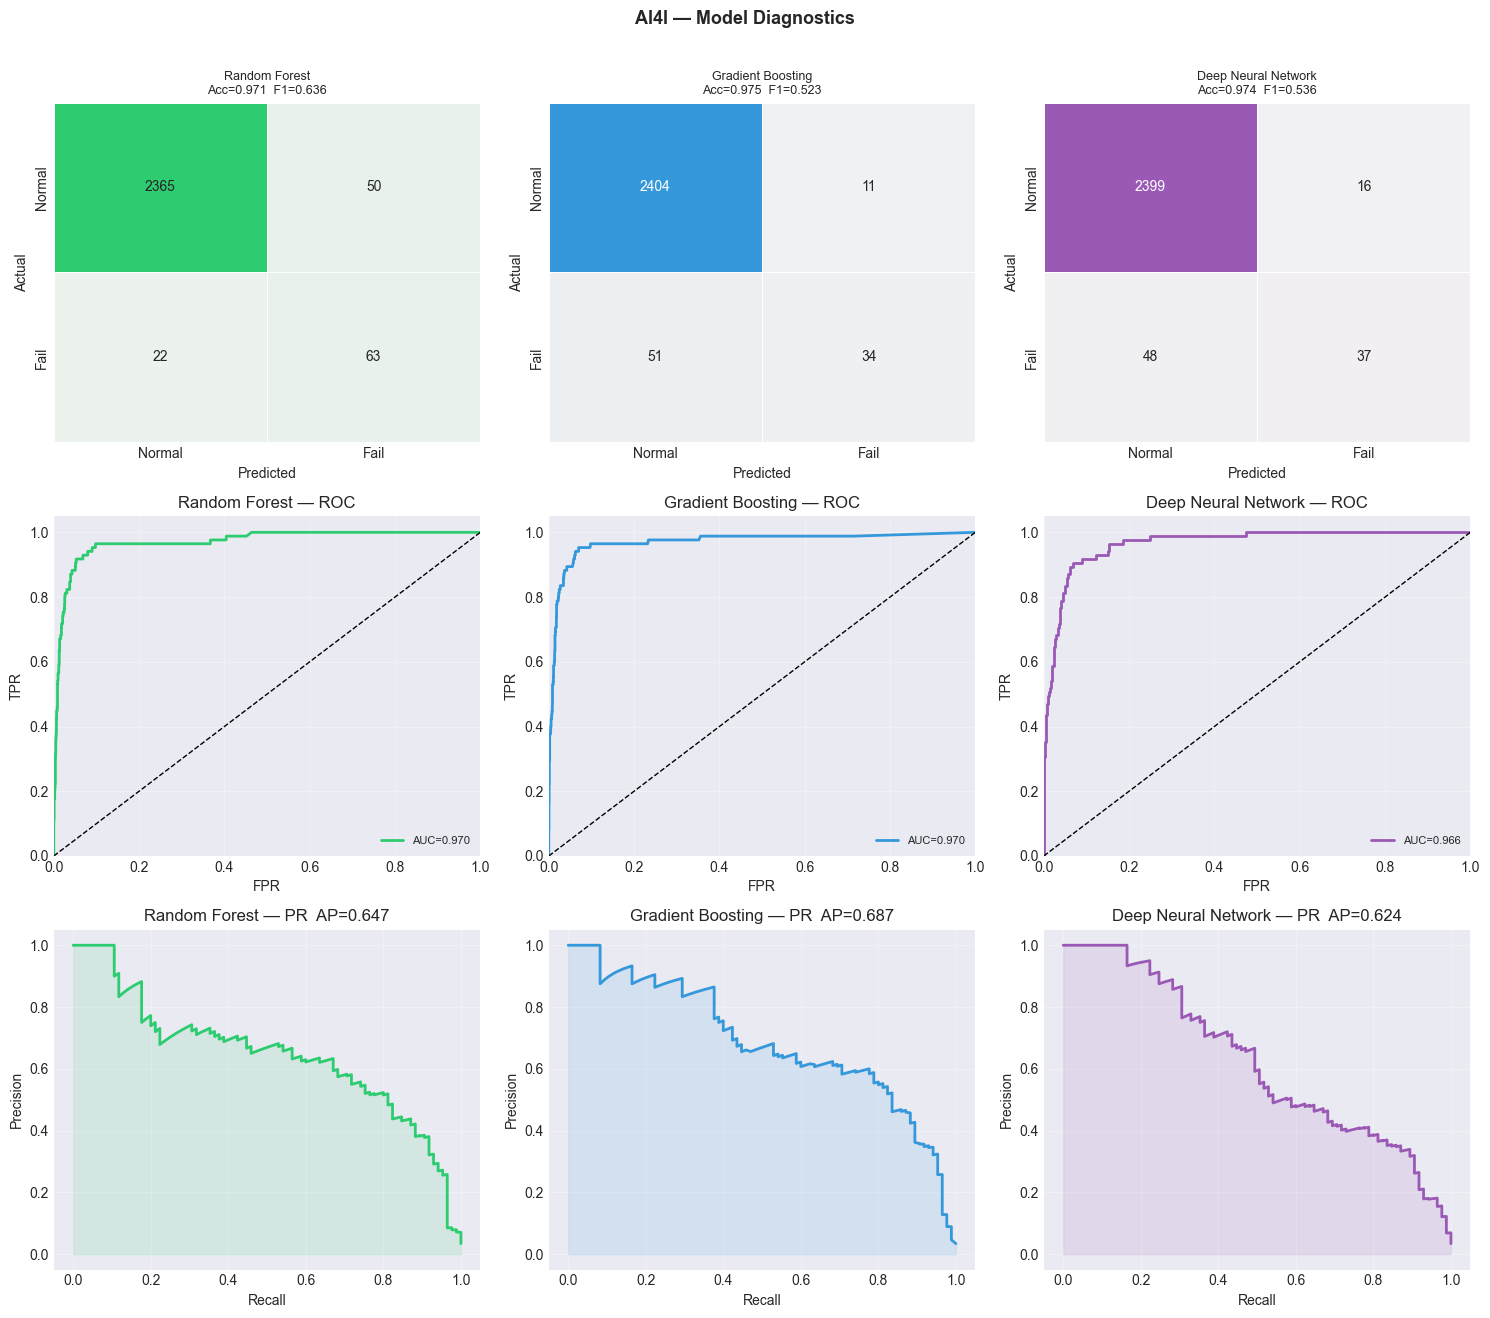

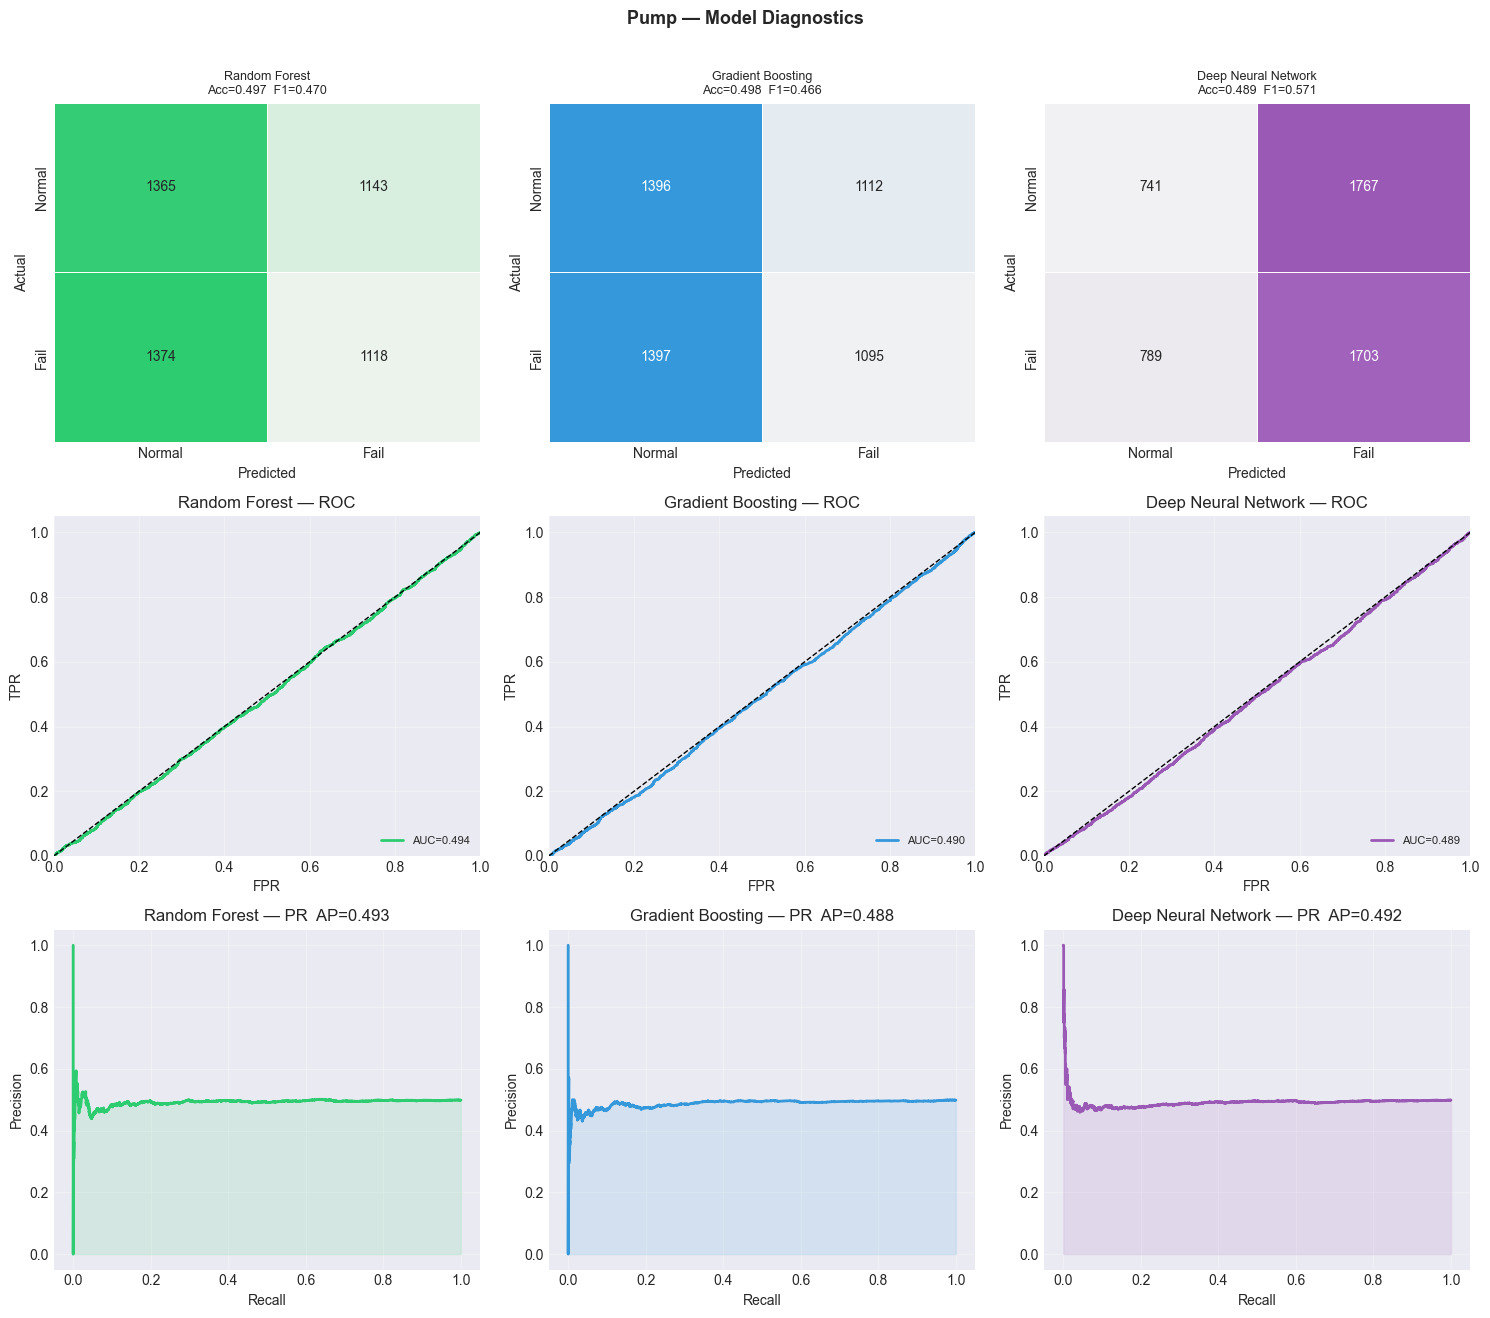

In [24]:
# Cell 9: Per-dataset diagnostic plots (confusion matrices + ROC + PR)
def plot_diagnostics(preds, probs, y_test, dataset_name, palette):
    model_names = list(preds.keys())
    fig, axes = plt.subplots(3, 3, figsize=(15, 13))

    for col, name in enumerate(model_names):
        y_pred = preds[name]; y_prob = probs[name]
        clr = palette[col]

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        cmap = sns.light_palette(clr, as_cmap=True)
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[0,col],
                    xticklabels=['Normal','Fail'], yticklabels=['Normal','Fail'],
                    linewidths=0.5, cbar=False)
        f1  = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
        acc = accuracy_score(y_test, y_pred)
        axes[0,col].set_title(f'{name}\nAcc={acc:.3f}  F1={f1:.3f}', fontsize=9)
        axes[0,col].set_xlabel('Predicted'); axes[0,col].set_ylabel('Actual')

        # ROC
        fpr,tpr,_ = roc_curve(y_test, y_prob)
        roc_auc   = auc(fpr,tpr)
        axes[1,col].plot(fpr,tpr,lw=2,color=clr,label=f'AUC={roc_auc:.3f}')
        axes[1,col].plot([0,1],[0,1],'k--',lw=1)
        axes[1,col].set(xlim=[0,1],ylim=[0,1.05],xlabel='FPR',ylabel='TPR',
                        title=f'{name} — ROC')
        axes[1,col].legend(loc='lower right',fontsize=8); axes[1,col].grid(alpha=0.3)

        # PR
        prec,rec,_ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        axes[2,col].plot(rec,prec,lw=2,color=clr)
        axes[2,col].fill_between(rec,prec,alpha=0.12,color=clr)
        axes[2,col].set(xlabel='Recall',ylabel='Precision',
                        title=f'{name} — PR  AP={ap:.3f}')
        axes[2,col].grid(alpha=0.3)

    plt.suptitle(f'{dataset_name} — Model Diagnostics', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

palette = ['#2ecc71','#3498db','#9b59b6']
plot_diagnostics(pr_ai4i,  pb_ai4i,  yt_ai4i,  'AI4I',   palette)
plot_diagnostics(pr_pump,  pb_pump,  yt_pump,  'Pump',   palette)


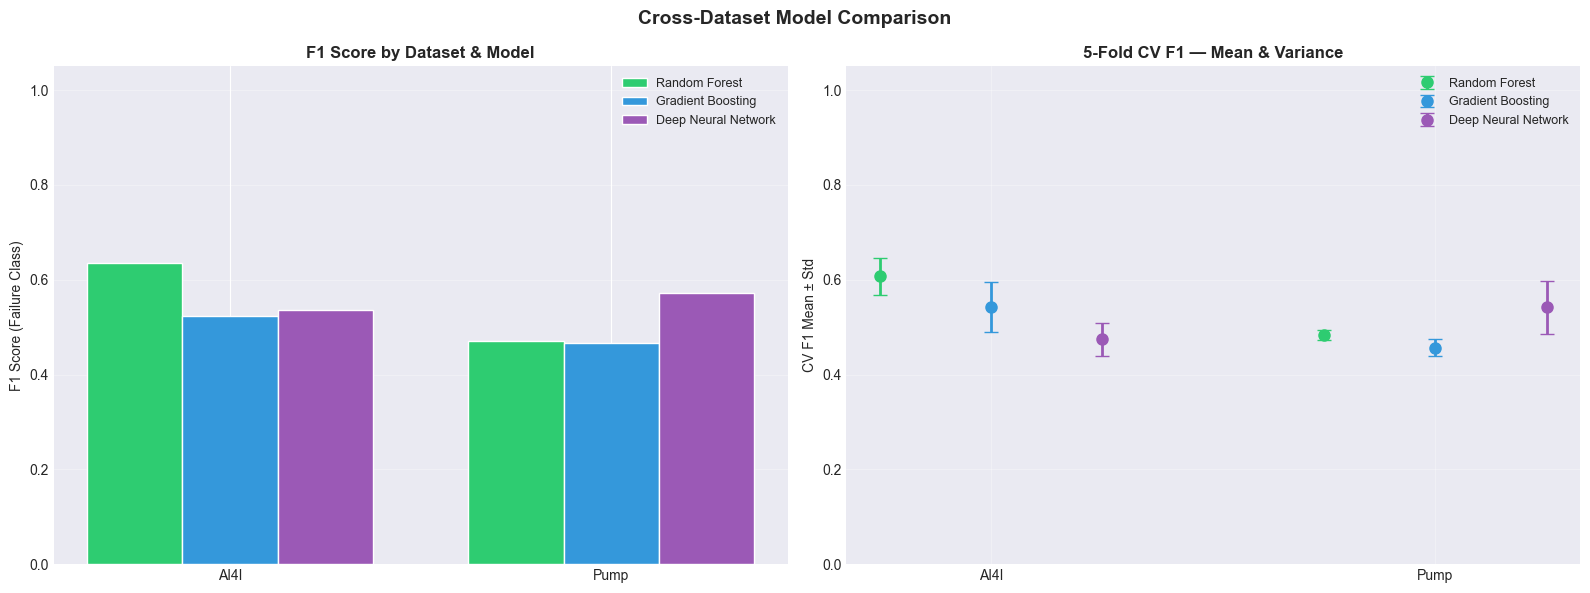

In [23]:
# Cell 10: Cross-dataset comparison — F1 bar chart + CV boxplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 grouped bar by dataset
datasets_order = ['AI4I','Pump']
models_order   = ['Random Forest','Gradient Boosting','Deep Neural Network']
model_colors   = {'Random Forest':'#2ecc71','Gradient Boosting':'#3498db','Deep Neural Network':'#9b59b6'}

x     = np.arange(len(datasets_order))
width = 0.25
for i, model in enumerate(models_order):
    subset = all_results[all_results['algorithm']==model]
    vals   = [subset[subset['dataset']==d]['f1'].values[0]
              if len(subset[subset['dataset']==d]) else 0
              for d in datasets_order]
    axes[0].bar(x + i*width, vals, width, label=model,
                color=model_colors[model], edgecolor='white')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(datasets_order)
axes[0].set_ylabel('F1 Score (Failure Class)')
axes[0].set_title('F1 Score by Dataset & Model', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].set_ylim(0,1.05); axes[0].grid(alpha=0.3,axis='y')

# CV F1 mean ± std
for i, model in enumerate(models_order):
    subset = all_results[all_results['algorithm']==model]
    for j, ds in enumerate(datasets_order):
        row = subset[subset['dataset']==ds]
        if len(row):
            axes[1].errorbar(j + i*0.25 - 0.25, row['cv_f1_mean'].values[0],
                             yerr=row['cv_f1_std'].values[0],
                             fmt='o', color=model_colors[model],
                             markersize=8, capsize=5, linewidth=2,
                             label=model if j==0 else '')

axes[1].set_xticks(np.arange(len(datasets_order)))
axes[1].set_xticklabels(datasets_order)
axes[1].set_ylabel('CV F1 Mean ± Std')
axes[1].set_title('5-Fold CV F1 — Mean & Variance', fontsize=12, fontweight='bold')
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[:3], labels[:3], fontsize=9)
axes[1].set_ylim(0,1.05); axes[1].grid(alpha=0.3)

plt.suptitle('Cross-Dataset Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


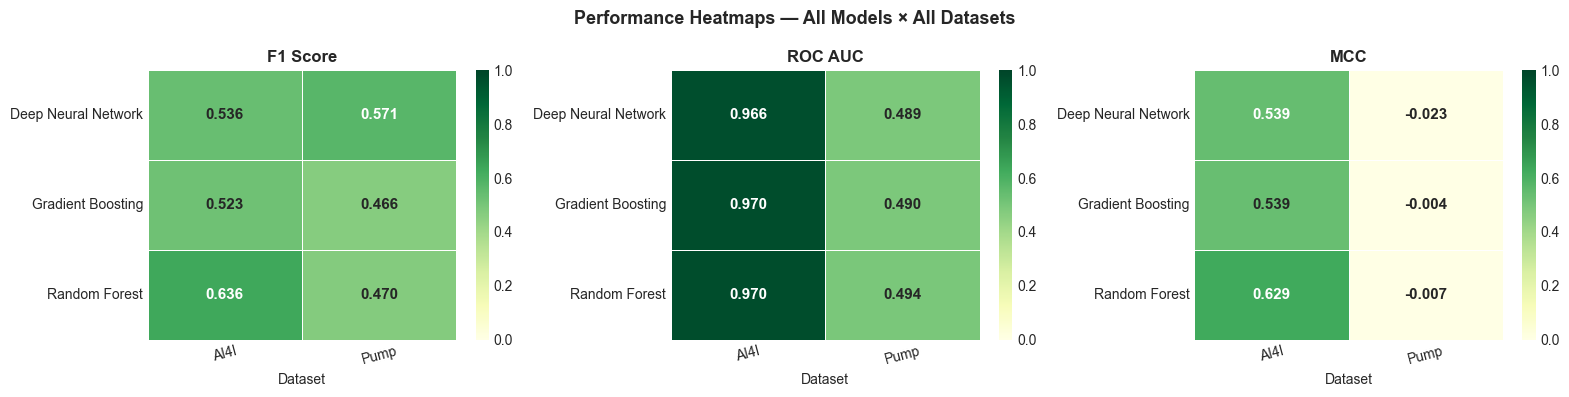

In [19]:
# Cell 11: Metric heatmap — all models × all datasets
pivot_f1  = all_results.pivot_table(index='algorithm', columns='dataset', values='f1')
pivot_auc = all_results.pivot_table(index='algorithm', columns='dataset', values='roc_auc')
pivot_mcc = all_results.pivot_table(index='algorithm', columns='dataset', values='mcc')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, pivot, title in zip(axes,
    [pivot_f1, pivot_auc, pivot_mcc],
    ['F1 Score', 'ROC AUC', 'MCC']):
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
                linewidths=0.5, vmin=0, vmax=1,
                annot_kws={'size':11,'weight':'bold'})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Dataset'); ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Performance Heatmaps — All Models × All Datasets',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


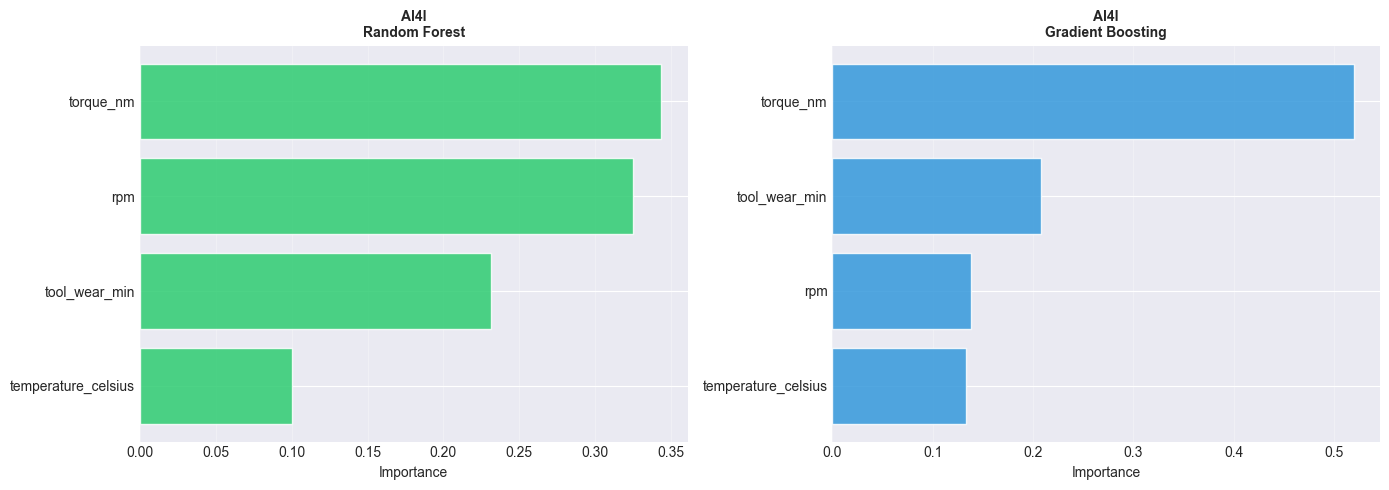

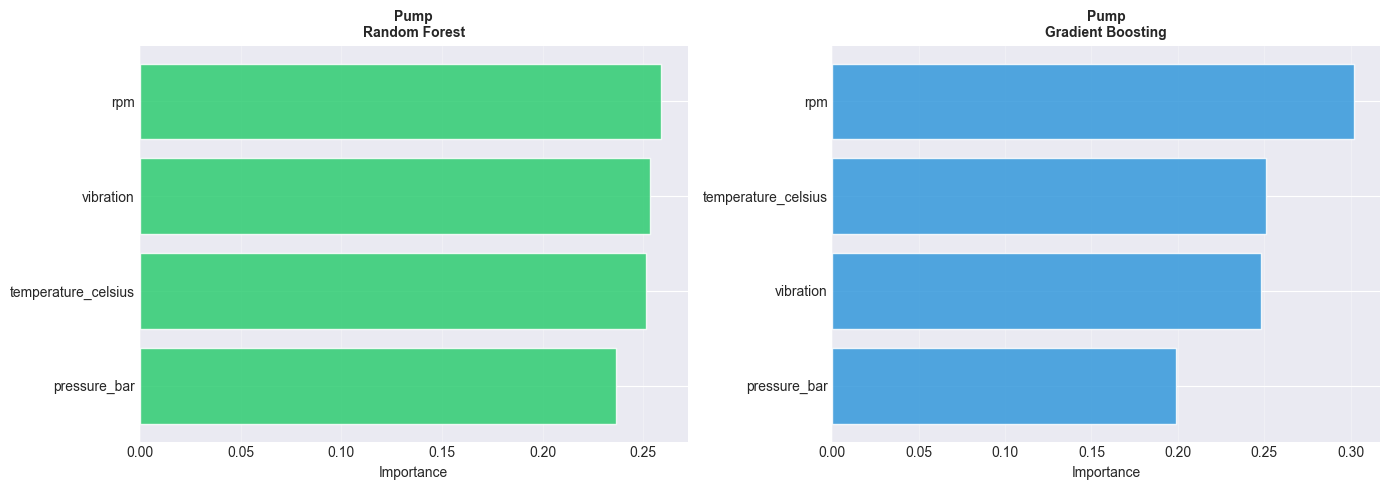

In [21]:
# Cell 12: Feature importance (RF + GB) per dataset
def plot_feature_importance(trained_models, feature_cols, dataset_name):
    tree_models = {k:v for k,v in trained_models.items()
                   if 'Forest' in k or 'Boosting' in k}
    fig, axes = plt.subplots(1, len(tree_models), figsize=(7*len(tree_models), 5))
    if len(tree_models)==1: axes=[axes]
    colors = ['#2ecc71','#3498db']
    for ax,(name,pipe),clr in zip(axes,tree_models.items(),colors):
        imp = pd.Series(pipe.named_steps['model'].feature_importances_,
                        index=feature_cols).sort_values()
        ax.barh(imp.index, imp.values, color=clr, alpha=0.85, edgecolor='white')
        ax.set_title(f'{dataset_name}\n{name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Importance'); ax.grid(alpha=0.3, axis='x')
    plt.tight_layout(); plt.show()

plot_feature_importance(tr_ai4i,   ai4i_feat,   'AI4I')
plot_feature_importance(tr_pump,   pump_feat,   'Pump')


In [25]:
# Cell 13: Maintenance plan from best model per dataset
def make_status(p):
    return ("failure imminent"    if p >= 0.70 else
            "maintenance required" if p >= 0.35 else "normal")

def make_strategy(status):
    if status == "failure imminent":
        return "Stop equipment, inspect within 24 h, prepare spare parts."
    if status == "maintenance required":
        return "Schedule preventive maintenance; monitor sensor trend."
    return "Continue normal operation with routine monitoring."

plans = []
for df_src, preds_d, probs_d, res_d, name in [
    (df_ai4i,   pr_ai4i,   pb_ai4i,   res_ai4i,   'AI4I'),
    (df_pump,   pr_pump,   pb_pump,   res_pump,   'Pump')
]:
    best_model = res_d.sort_values('f1', ascending=False).iloc[0]['algorithm']
    probs_best = pb_ai4i[best_model] if name=='AI4I' else (
                 pb_pump[best_model] if name=='Pump' else pb_scania[best_model])
    status = [make_status(p) for p in probs_best]
    strat  = [make_strategy(s) for s in status]
    plan   = pd.DataFrame({
        'dataset':             name,
        'best_model':          best_model,
        'failure_probability': probs_best,
        'predicted_status':    status,
        'maintenance_strategy':strat,
    })
    plans.append(plan)
    print(f"\n{name} — Best model: {best_model}")
    print(plan['predicted_status'].value_counts().to_string())

full_plan = pd.concat(plans, ignore_index=True)



AI4I — Best model: Random Forest
predicted_status
normal                  2331
maintenance required     102
failure imminent          67

Pump — Best model: Deep Neural Network
predicted_status
maintenance required    5000


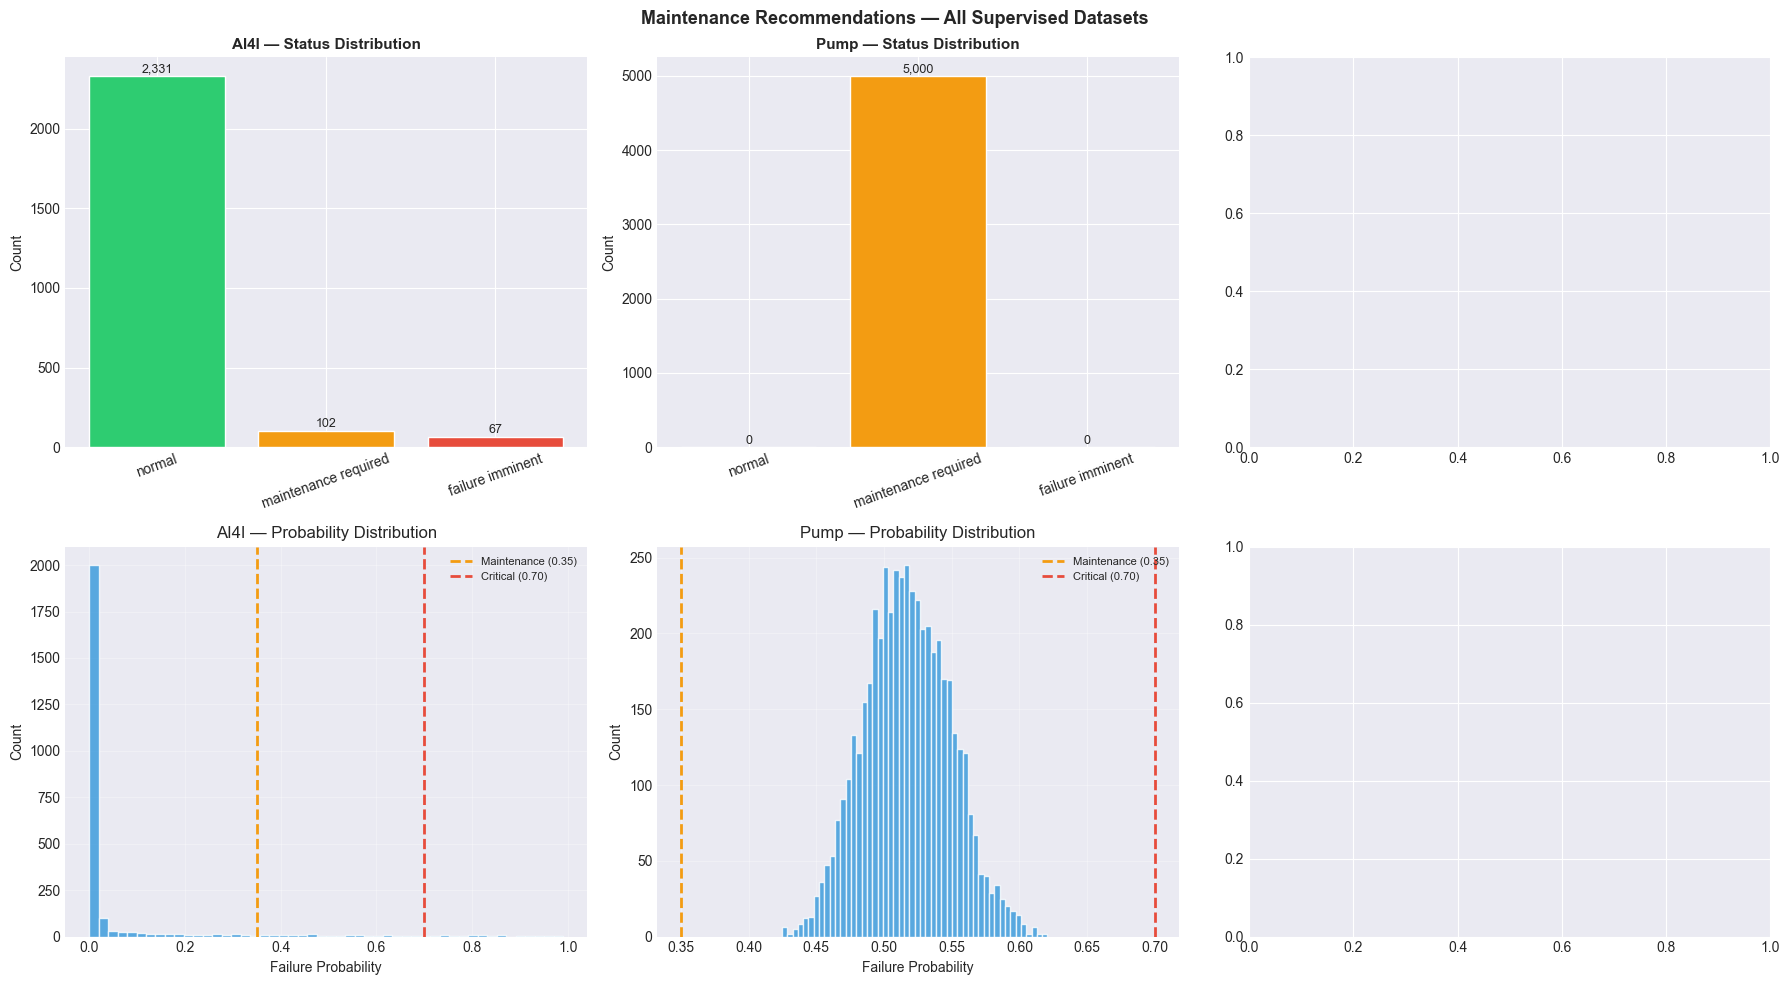

In [27]:
# Cell 14: Maintenance plan visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
status_colors = {'normal':'#2ecc71','maintenance required':'#f39c12','failure imminent':'#e74c3c'}
status_order  = ['normal','maintenance required','failure imminent']

for col, (plan, name) in enumerate(zip(plans, ['AI4I','Pump'])):
    counts = plan['predicted_status'].value_counts().reindex(status_order, fill_value=0)
    axes[0,col].bar(counts.index, counts.values,
                    color=[status_colors[s] for s in counts.index], edgecolor='white')
    axes[0,col].set_title(f'{name} — Status Distribution', fontsize=11, fontweight='bold')
    axes[0,col].set_ylabel('Count'); axes[0,col].tick_params(axis='x',rotation=20)
    for i,(s,v) in enumerate(zip(counts.index,counts.values)):
        axes[0,col].text(i, v+max(counts)*0.01, f'{v:,}', ha='center', fontsize=9)

    axes[1,col].hist(plan['failure_probability'], bins=50, color='#3498db',
                     edgecolor='white', alpha=0.8)
    axes[1,col].axvline(0.35, color='#f39c12', ls='--', lw=2, label='Maintenance (0.35)')
    axes[1,col].axvline(0.70, color='#e74c3c', ls='--', lw=2, label='Critical (0.70)')
    axes[1,col].set(xlabel='Failure Probability', ylabel='Count',
                    title=f'{name} — Probability Distribution')
    axes[1,col].legend(fontsize=8); axes[1,col].grid(alpha=0.3)

plt.suptitle('Maintenance Recommendations — All Supervised Datasets',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
# Cell 15: Save JSON outputs
output_dir = Path("model_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

results_json = []
for _, r in all_results.iterrows():
    results_json.append({k: (round(float(v),6) if isinstance(v,float) else v)
                         for k,v in r.items()})

descriptor = {
    "notebook":        "supervised",
    "generated_at":    datetime.utcnow().isoformat()+"Z",
    "task":            "binary_classification | 0=Normal 1=Failure",
    "datasets": {
        "AI4I":   {"rows": len(df_ai4i),   "failure_rate_pct": round(df_ai4i['label_binary'].mean()*100,3)},
        "Pump":   {"rows": len(df_pump),   "failure_rate_pct": round(df_pump['label_binary'].mean()*100,3)},
        "SCANIA": {"rows": len(df_scania), "failure_rate_pct": round(df_scania['label_binary'].mean()*100,3)},
    },
    "note_metropt3": "MetroPT3 excluded — no ground-truth labels. See modeling_unsupervised.ipynb.",
    "models":  results_json,
    "best_per_dataset": {
        ds: all_results[all_results['dataset']==ds].sort_values('f1',ascending=False)
            .iloc[0][['algorithm','f1','roc_auc','mcc']].to_dict()
        for ds in ['AI4I','Pump','SCANIA']
    },
}

with open(output_dir/"supervised_results.json","w") as f:
    json.dump(descriptor, f, indent=2)

full_plan.to_csv(output_dir/"supervised_maintenance_plan.csv", index=False)
all_results.to_csv(output_dir/"supervised_metrics.csv", index=False)

print("Saved:")
for fp in sorted(output_dir.glob("supervised*")):
    print(f"  {fp.name}")
